# 04 - Phân tích sự thay đổi của Behavioral Profiles theo thời gian

1. Persona có tương ứng với vòng đời khách hàng không, khách càng lâu năm có xu hướng rơi vào persona nào?  
2. Trong cùng một giai đoạn vòng đời, các persona có hành vi khác nhau không, hay chỉ vì persona = tenure khác nhau?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

feat = pd.read_parquet('data/clustered_users.parquet')            # mức khách hàng (1 dòng/user, có persona)
order_lvl = pd.read_parquet('data/order_level.parquet')            # mức đơn hàng (từ notebook 01)


K = feat['cluster'].nunique()
print('Số khách hàng:', feat.shape[0], '| Số persona:', K)
print('Số đơn hàng (mức order):', order_lvl.shape[0])

# Gắn nhãn persona của khách vào từng đơn hàng của họ
order_p = order_lvl.merge(feat[['user_id', 'cluster', 'cluster_name']], on='user_id', how='inner')
print('Số đơn hàng đã gắn persona:', order_p.shape[0])

Số khách hàng: 70268 | Số persona: 5
Số đơn hàng (mức order): 103761
Số đơn hàng đã gắn persona: 103761


# 1. Persona có tương ứng với thâm niên khách không

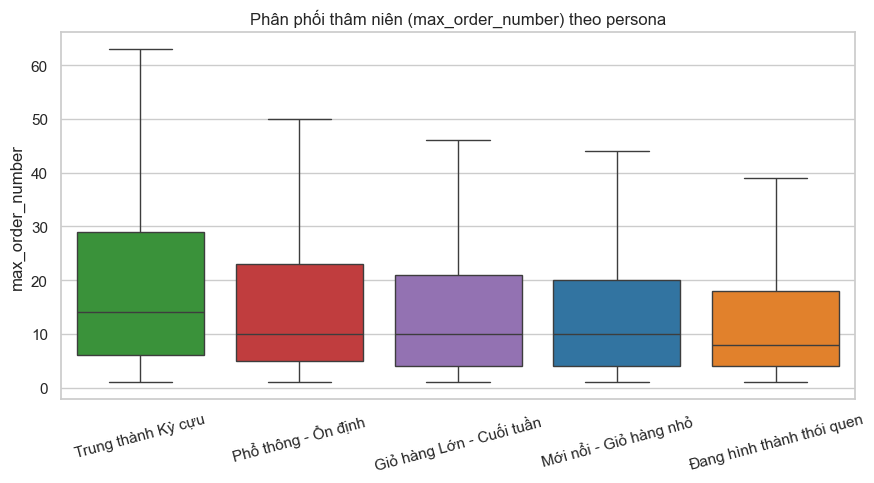

cluster_name
Trung thành Kỳ cựu           14.0
Giỏ hàng Lớn - Cuối tuần     10.0
Mới nổi - Giỏ hàng nhỏ       10.0
Phổ thông - Ổn định          10.0
Đang hình thành thói quen     8.0
Name: max_order_number, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(9,5))
order_persona = feat.groupby('cluster_name')['max_order_number'].mean().sort_values(ascending=False).index
sns.boxplot(data=feat, x='cluster_name', y='max_order_number', order=order_persona, ax=ax, palette='tab10',
            hue='cluster_name', legend=False, showfliers=False)
ax.set_title('Phân phối thâm niên (max_order_number) theo persona')
ax.set_xlabel(''); ax.set_ylabel('max_order_number')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(feat.groupby('cluster_name')['max_order_number'].median().sort_values(ascending=False))

#### 1.1 Cơ cấu persona theo vòng đời

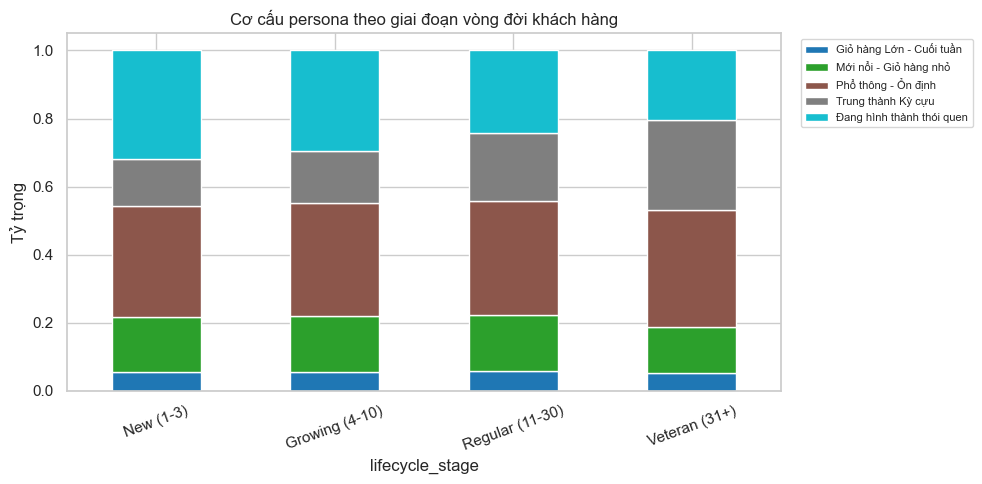

cluster_name,Giỏ hàng Lớn - Cuối tuần,Mới nổi - Giỏ hàng nhỏ,Phổ thông - Ổn định,Trung thành Kỳ cựu,Đang hình thành thói quen
lifecycle_stage,,,,,
New (1-3),0.053,0.162,0.328,0.139,0.318
Growing (4-10),0.055,0.165,0.331,0.155,0.295
Regular (11-30),0.059,0.163,0.335,0.202,0.241
Veteran (31+),0.050,0.135,0.347,0.264,0.203


In [6]:
bins = [0, 3, 10, 30, 100]
labels = ['New (1-3)', 'Growing (4-10)', 'Regular (11-30)', 'Veteran (31+)']
feat['lifecycle_stage'] = pd.cut(feat['max_order_number'], bins=bins, labels=labels)

cluster_by_stage = pd.crosstab(feat['lifecycle_stage'], feat['cluster_name'], normalize='index').reindex(labels)

fig, ax = plt.subplots(figsize=(10,5))
cluster_by_stage.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Cơ cấu persona theo giai đoạn vòng đời khách hàng')
ax.set_ylabel('Tỷ trọng')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

cluster_by_stage.round(3)

đúng như dự đoán, tỷ trọng **"Trung thành Kỳ cựu"** tăng mạnh khi tenure tăng, trong khi **"Đang hình thành thói quen"**/**"Mới nổi"** chiếm tỷ trọng lớn ở nhóm New/Growing rồi giảm dần

## 2. Kiểm soát tenure: reorder rate theo order_number, tách theo persona

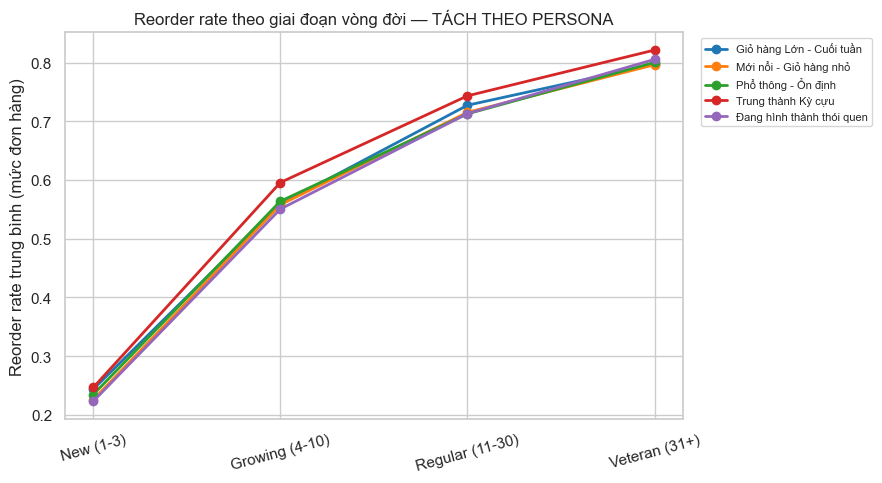

lifecycle_stage,New (1-3),Growing (4-10),Regular (11-30),Veteran (31+)
cluster_name,,,,
Giỏ hàng Lớn - Cuối tuần,0.244,0.559,0.727,0.797
Mới nổi - Giỏ hàng nhỏ,0.226,0.558,0.715,0.796
Phổ thông - Ổn định,0.235,0.564,0.713,0.800
Trung thành Kỳ cựu,0.247,0.596,0.743,0.821
Đang hình thành thói quen,0.223,0.550,0.713,0.805


In [7]:
order_p['lifecycle_stage'] = pd.cut(order_p['order_number'], bins=bins, labels=labels)

reorder_trend = order_p.groupby(['cluster_name', 'lifecycle_stage'], observed=True)['reorder_rate'].mean().unstack()[labels]

fig, ax = plt.subplots(figsize=(9,5))
palette = sns.color_palette('tab10', K)
for i, cname in enumerate(reorder_trend.index):
    ax.plot(labels, reorder_trend.loc[cname], marker='o', linewidth=2, label=cname, color=palette[i])
ax.set_title('Reorder rate theo giai đoạn vòng đời — TÁCH THEO PERSONA')
ax.set_ylabel('Reorder rate trung bình (mức đơn hàng)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

reorder_trend.round(3)

**Insight** ngay cả khi kiểm soát theo giai đoạn vòng đời, **"Trung thành Kỳ cựu" luôn có reorder rate cao nhất ở MỌI giai đoạn** — kể cả ở nhóm "New (1-3)" (24.7% so với 22.3-24.4% của các persona khác) lẫn "Veteran (31+)" (82.1% so với 79.6-80.5%). Nghĩa là ngay từ những đơn hàng đầu tiên, nhóm khách hàng này đã có xu hướng mua lặp lại cao hơn — đây là một **tín hiệu hành vi có thể dùng để dự đoán sớm khách hàng tiềm năng trung thành**, không cần đợi họ tích luỹ nhiều đơn hàng mới nhận diện được. Ngược lại, **"Đang hình thành thói quen"** khởi đầu thấp nhất (22.3%) nhưng bắt kịp khá nhanh ở giai đoạn Veteran.

## 3. Kiểm soát tenure: kích thước giỏ hàng theo order_number, tách theo persona

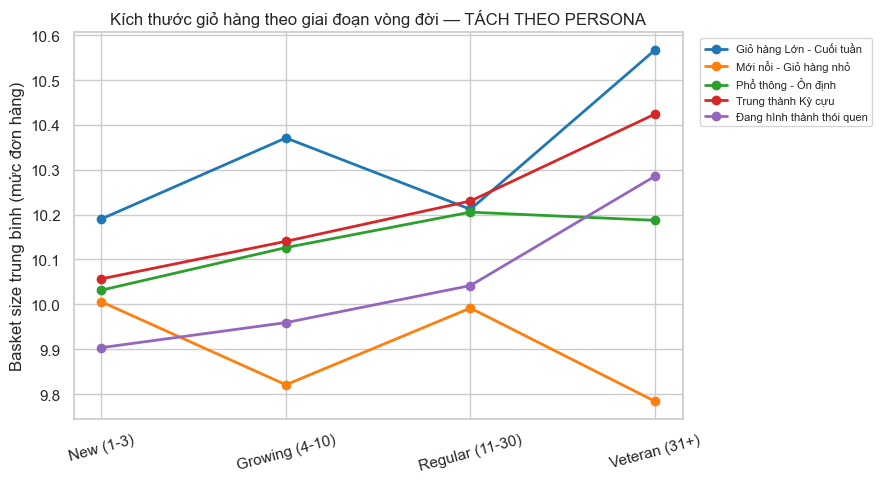

lifecycle_stage,New (1-3),Growing (4-10),Regular (11-30),Veteran (31+)
cluster_name,,,,
Giỏ hàng Lớn - Cuối tuần,10.19,10.37,10.21,10.57
Mới nổi - Giỏ hàng nhỏ,10.01,9.82,9.99,9.78
Phổ thông - Ổn định,10.03,10.13,10.21,10.19
Trung thành Kỳ cựu,10.06,10.14,10.23,10.42
Đang hình thành thói quen,9.90,9.96,10.04,10.29


In [8]:
basket_trend = order_p.groupby(['cluster_name', 'lifecycle_stage'], observed=True)['basket_size'].mean().unstack()[labels]

fig, ax = plt.subplots(figsize=(9,5))
for i, cname in enumerate(basket_trend.index):
    ax.plot(labels, basket_trend.loc[cname], marker='o', linewidth=2, label=cname, color=palette[i])
ax.set_title('Kích thước giỏ hàng theo giai đoạn vòng đời — TÁCH THEO PERSONA')
ax.set_ylabel('Basket size trung bình (mức đơn hàng)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

basket_trend.round(2)

**Insight:** **"Giỏ hàng Lớn — Cuối tuần"** duy trì basket size cao nhất xuyên suốt mọi giai đoạn (10.19 → 10.57) — đây là đặc điểm hành vi ổn định, không phải hiệu ứng tenure.   
**"Mới nổi — Giỏ hàng nhỏ"** là persona duy nhất có basket size **giảm nhẹ** theo tenure (10.01 → 9.78) thay vì tăng — đáng chú ý vì ngược chiều xu hướng chung, gợi ý nhóm này có thể đang "thu hẹp" giỏ hàng về các mặt hàng thiết yếu lặp lại thay vì mở rộng.

## 4. Dịch chuyển hành vi CÁ NHÂN (khách có ≥2 đơn quan sát), theo persona

In [9]:
order_sorted = order_p.sort_values(['user_id', 'order_number'])
counts_per_user = order_sorted.groupby('user_id').size()
multi_users = counts_per_user[counts_per_user >= 2].index
multi = order_sorted[order_sorted['user_id'].isin(multi_users)]

first_last = multi.groupby('user_id').agg(
    cluster_name=('cluster_name', 'first'),
    first_basket=('basket_size', 'first'), last_basket=('basket_size', 'last'),
    first_reorder=('reorder_rate', 'first'), last_reorder=('reorder_rate', 'last'),
)
first_last['basket_delta'] = first_last['last_basket'] - first_last['first_basket']
first_last['reorder_delta'] = first_last['last_reorder'] - first_last['first_reorder']

print(f'Số khách hàng có ≥2 đơn quan sát: {len(first_last):,} / {feat.shape[0]:,} tổng khách hàng')
drift_by_persona = first_last.groupby('cluster_name')[['basket_delta', 'reorder_delta']].mean()
drift_by_persona

Số khách hàng có ≥2 đơn quan sát: 21,822 / 70,268 tổng khách hàng


,basket_delta,reorder_delta
cluster_name,,
Giỏ hàng Lớn - Cuối tuần,0.239754,0.147886
Mới nổi - Giỏ hàng nhỏ,0.078282,0.157076
Phổ thông - Ổn định,0.340833,0.158468
Trung thành Kỳ cựu,0.370254,0.151870
Đang hình thành thói quen,0.161413,0.191398


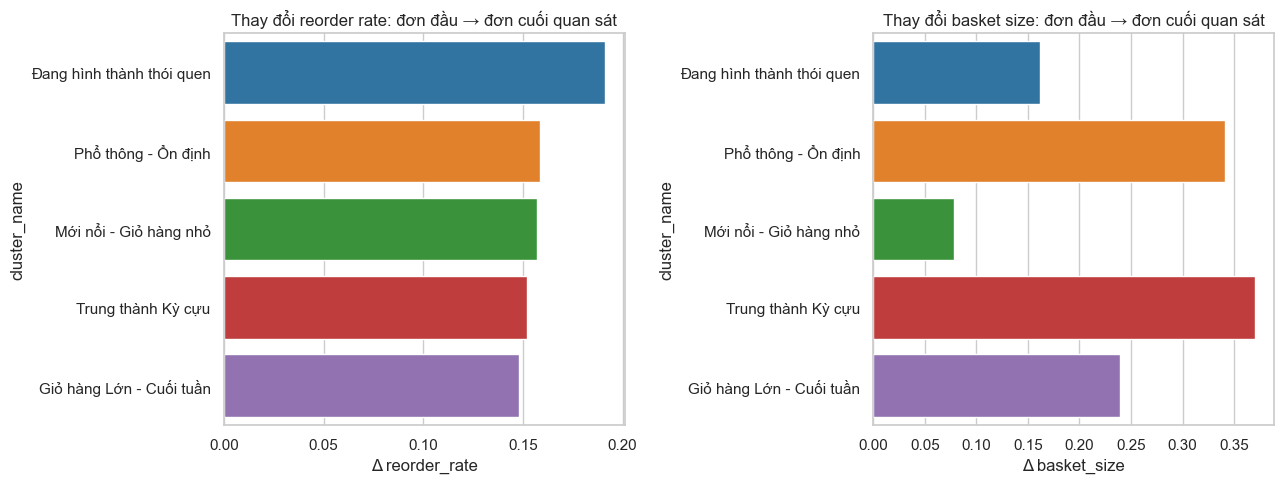

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
order_drift = drift_by_persona['reorder_delta'].sort_values(ascending=False).index

sns.barplot(x=drift_by_persona.loc[order_drift, 'reorder_delta'], y=order_drift, ax=axes[0], palette='tab10',
            hue=order_drift, legend=False)
axes[0].set_title('Thay đổi reorder rate: đơn đầu → đơn cuối quan sát')
axes[0].set_xlabel('Δ reorder_rate')

sns.barplot(x=drift_by_persona.loc[order_drift, 'basket_delta'], y=order_drift, ax=axes[1], palette='tab10',
            hue=order_drift, legend=False)
axes[1].set_title('Thay đổi basket size: đơn đầu → đơn cuối quan sát')
axes[1].set_xlabel('Δ basket_size')
plt.tight_layout()
plt.show()

**"Đang hình thành thói quen"** có mức tăng reorder rate lớn nhất (+0.191) trong số các persona — xác nhận đúng bản chất "đang trong quá trình xây dựng thói quen mua lặp lại".  
**"Mới nổi — Giỏ hàng nhỏ"** có mức tăng basket size thấp nhất (+0.078) — nhóm này chưa cho thấy dấu hiệu mở rộng giỏ hàng rõ rệt trong dữ liệu quan sát được, cần theo dõi thêm hoặc có chiến lược kích thích chủ động hơn.   
**"Trung thành Kỳ cựu"** dù đã ở mức cao vẫn tiếp tục tăng basket size đáng kể (+0.370) — trung thành không đồng nghĩa với "chững lại", nhóm này vẫn đang tăng giá trị đơn hàng.

In [12]:
feat.to_parquet('data/final_with_lifecycle_user.parquet', index=False)
cluster_by_stage.to_csv('data/cluster_by_stage_user.csv')
reorder_trend.to_csv('data/reorder_trend_by_persona.csv')
basket_trend.to_csv('data/basket_trend_by_persona.csv')
drift_by_persona.to_csv('data/drift_by_persona.csv')

summary_stats = {
    'reorder_rate_new_avg': float(order_p[order_p['lifecycle_stage']=='New (1-3)']['reorder_rate'].mean()),
    'reorder_rate_veteran_avg': float(order_p[order_p['lifecycle_stage']=='Veteran (31+)']['reorder_rate'].mean()),
    'top_persona_reorder_new': reorder_trend['New (1-3)'].idxmax(),
    'top_persona_reorder_new_value': float(reorder_trend['New (1-3)'].max()),
    'n_multi_order_users': int(len(first_last)),
    'persona_max_reorder_delta': drift_by_persona['reorder_delta'].idxmax(),
    'persona_min_basket_delta': drift_by_persona['basket_delta'].idxmin(),
}

print('Đã lưu các file kết quả phân tích thời gian (bản hành vi khách hàng) cho notebook 05.')
print(json.dumps(summary_stats, indent=2, ensure_ascii=False))

Đã lưu các file kết quả phân tích thời gian (bản hành vi khách hàng) cho notebook 05.
{
  "reorder_rate_new_avg": 0.23249748079626728,
  "reorder_rate_veteran_avg": 0.8065936249865223,
  "top_persona_reorder_new": "Trung thành Kỳ cựu",
  "top_persona_reorder_new_value": 0.2466671477662573,
  "n_multi_order_users": 21822,
  "persona_max_reorder_delta": "Đang hình thành thói quen",
  "persona_min_basket_delta": "Mới nổi - Giỏ hàng nhỏ"
}


# Tóm tắt

1. **Persona tương quan rõ với thâm niên** (Trung thành Kỳ cựu = tenure cao nhất, Mới nổi/Đang hình thành = tenure thấp nhất) — đúng kỳ vọng vì tenure là 1 input của clustering.
2. **Nhưng quan trọng hơn: persona vẫn khác biệt NGAY CẢ KHI kiểm soát theo giai đoạn vòng đời** — "Trung thành Kỳ cựu" có reorder rate cao nhất ở mọi giai đoạn (kể cả lúc mới, 24.7% so với ~22-24%), "Giỏ hàng Lớn — Cuối tuần" luôn có basket size cao nhất xuyên suốt. → Persona phản ánh **hành vi thật**, không chỉ là tenure được đặt tên khác.
3. Ở cấp độ cá nhân, **"Đang hình thành thói quen"** cho thấy tốc độ tăng reorder rate nhanh nhất giữa các đơn quan sát — xác nhận đúng bản chất persona. **"Mới nổi — Giỏ hàng nhỏ"** gần như không tăng basket size — cần chiến lược kích thích chủ động hơn là chỉ chờ đợi.
4. **Hàm ý CRM:** vì persona "Trung thành Kỳ cựu" có thể nhận diện tín hiệu ngay từ những đơn hàng đầu (reorder rate cao bất thường so với nhóm cùng tenure), doanh nghiệp có thể xây dựng mô hình nhận diện sớm khách hàng tiềm năng trung thành mà không cần chờ tích luỹ nhiều đơn hàng.